Lista 7 - IA

In [ ]:
#questão 1
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine()
features = wine.feature_names

X = wine.data
Y = wine.target

df = pd.DataFrame(X, columns=features)
df.head()

#Vendo a natureza dos dados:
for feature in features:
    print(f'Coluna: {feature}')
    print(f'Quantidade de valores nulos: {df[feature].isnull().sum()}')
    print('\n')
    df[feature].info()
    print('\n')

#O dataset não precisa de limpeza, todos os dados são numéricos.




Coluna: alcohol
Quantidade de valores nulos: 0


<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: alcohol
Non-Null Count  Dtype  
--------------  -----  
178 non-null    float64
dtypes: float64(1)
memory usage: 1.5 KB


Coluna: malic_acid
Quantidade de valores nulos: 0


<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: malic_acid
Non-Null Count  Dtype  
--------------  -----  
178 non-null    float64
dtypes: float64(1)
memory usage: 1.5 KB


Coluna: ash
Quantidade de valores nulos: 0


<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: ash
Non-Null Count  Dtype  
--------------  -----  
178 non-null    float64
dtypes: float64(1)
memory usage: 1.5 KB


Coluna: alcalinity_of_ash
Quantidade de valores nulos: 0


<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: alcalinity_of_ash
Non-Null Count  Dtype  
--------------  -----  
178 non-null    float64
dtypes: 

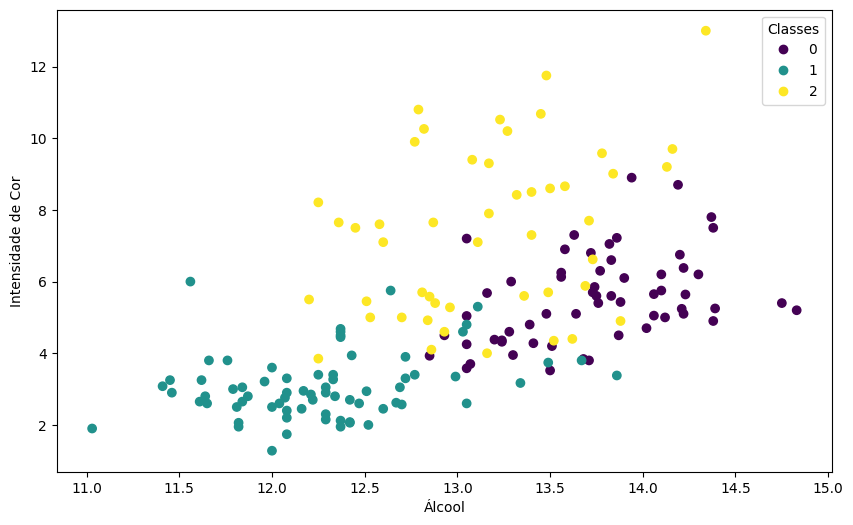

In [ ]:
#Questão 2

#irei escolher teor alcoólico e intensidade da cor como exemplo 

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['alcohol'], df['color_intensity'], c=Y, cmap='viridis')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel('Álcool')
plt.ylabel('Intensidade de Cor')
plt.show()

#Não parecem separados visualmente

In [ ]:
#Questão 3

from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import adjusted_rand_score

scaler = RobustScaler()
X_escalonado = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)

predict = kmeans.fit_predict(X_escalonado)

print(predict)
print('\n')

print(f'Inércia: {kmeans.inertia_}')
print('\n')

score = adjusted_rand_score(Y, predict)
print(f'Comparação entre os clusters e os grupos reais: {score}')
print(f'Cordenadas do kmeans: {kmeans.cluster_centers_}')



[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 2 0 0 0 2
 0 0 0 0 2 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


Inércia: 676.8168459745549
Comparação entre os clusters e os grupos reais: 0.8635987920128989
Cordenadas do kmeans: [[-0.6081236   0.03919991 -0.33573141  0.16242156 -0.36173768 -0.09028481
  -0.04167855  0.12698413  0.0531746  -0.57776712  0.27941211  0.02189381
  -0.35177814]
 [ 0.06396779  0.97449656  0.16589082  0.40492476  0.03508772 -0.63458953
  -0.78812962  0.66842259 -0.58445378  0.85392814 -0.80900508 -0.87897228
  -0.11236569]
 [ 0.44320342  0.07062922  0.25044964 -0.48582849  0.58305921  0.43705674
   0.49298278 -0.29477612  0.55602679  0.23180579  0.30740741  0.29906187
   0.85713364]]


K: 1 | ARS: 0.0000 | Inércia: 1148.59
K: 2 | ARS: 0.3887 | Inércia: 854.67
K: 3 | ARS: 0.8636 | Inércia: 676.82
K: 4 | ARS: 0.7258 | Inércia: 623.00
K: 5 | ARS: 0.6094 | Inércia: 581.17
K: 6 | ARS: 0.4456 | Inércia: 547.69
K: 7 | ARS: 0.3883 | Inércia: 517.29
K: 8 | ARS: 0.4353 | Inércia: 491.18
K: 9 | ARS: 0.4109 | Inércia: 485.32
K: 10 | ARS: 0.3925 | Inércia: 473.77


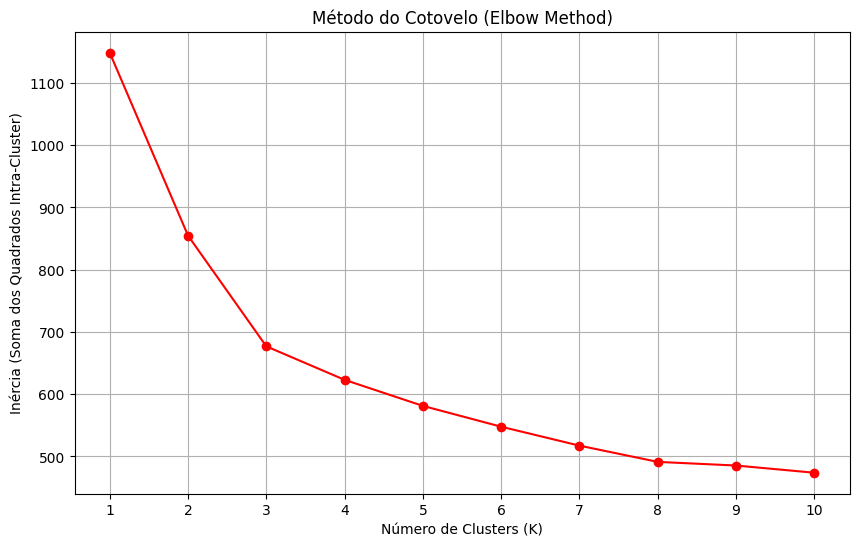

In [ ]:
#Questão 4

ks = range(1,11)
inercias = []

for k in ks:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    predict = kmeans.fit_predict(X_escalonado)
    inercia = kmeans.inertia_
    score = adjusted_rand_score(Y, predict)

    inercias.append(inercia)

    print(f'K: {k} , ARS: {score:.4f} , Inércia: {inercia:.2f}')

#As mudanças mais abruptas são no 3 e 4. Já sabemos pelo dataset que são 3 classes, logo
#três clusters. O gráfico não contribui muito para realizar o teste do cotovelo. Provavel
#mente por razões relacionadas ao dataset.

plt.figure(figsize=(10, 6))
plt.plot(ks, inercias, 'ro-')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma dos Quadrados Intra-Cluster)')
plt.xticks(ks)
plt.grid(True)
plt.show()